### Problem 1:

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

DATA_PATH   = "spambase.data"
TEST_SIZE   = 0.30
RANDOM_SEED = 42
MAX_DEPTH   = 30

#loading data
data = pd.read_csv(DATA_PATH, header=None)
X = data.iloc[:, :57].values
y = data.iloc[:, 57].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Dataset:   {len(data)} samples  |  57 features")
print(f"Train set: {len(X_train)} samples  |  "
      f"Test set: {len(X_test)} samples")
print(f"Class balance — Spam: {y.mean()*100:.1f}%  |  "
      f"Ham: {(1-y.mean())*100:.1f}%\n")

Dataset:   4601 samples  |  57 features
Train set: 3220 samples  |  Test set: 1381 samples
Class balance — Spam: 39.4%  |  Ham: 60.6%



In [130]:

#evaluation metric functins
def evaluate(clf, X_tr, y_tr, X_te, y_te):
    """Return a dict of train/test metrics for a fitted classifier."""
    y_tr_pred = clf.predict(X_tr)
    y_te_pred = clf.predict(X_te)
    y_te_prob = clf.predict_proba(X_te)[:, 1]
    return {
        "train_error": 1 - accuracy_score(y_tr, y_tr_pred),
        "test_error":  1 - accuracy_score(y_te, y_te_pred),
        "train_acc":   accuracy_score(y_tr, y_tr_pred),
        "test_acc":    accuracy_score(y_te, y_te_pred),
        "train_f1":    f1_score(y_tr, y_tr_pred),
        "test_f1":     f1_score(y_te, y_te_pred),
        "test_auc":    roc_auc_score(y_te, y_te_prob),
    }


def print_metrics(label, m, depth=None):
    print(f"\n{'─'*55}")
    print(f"  {label}")
    if depth is not None:
        print(f"  (tree depth: {depth})")
    print(f"{'─'*55}")
    print(f"  {'Metric':<22} {'Train':>10} {'Test':>10}")
    print(f"  {'─'*50}")
    print(f"  {'Error':<22} {m['train_error']:>10.4f} {m['test_error']:>10.4f}")
    print(f"  {'Accuracy':<22} {m['train_acc']:>10.4f} {m['test_acc']:>10.4f}")
    print(f"  {'F1 Score':<22} {m['train_f1']:>10.4f} {m['test_f1']:>10.4f}")
    print(f"  {'AUC (test only)':<22} {'—':>10} {m['test_auc']:>10.4f}")

In [131]:

# 1) base models. no pruning
print("Unpruned Decision Trees")
print("-" * 55)

# Information Gain (entropy)
clf_ig = DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_SEED)
clf_ig.fit(X_train, y_train)
m_ig = evaluate(clf_ig, X_train, y_train, X_test, y_test)
print_metrics("Criterion: Information Gain (Entropy)", m_ig, clf_ig.get_depth())


Unpruned Decision Trees
-------------------------------------------------------

───────────────────────────────────────────────────────
  Criterion: Information Gain (Entropy)
  (tree depth: 20)
───────────────────────────────────────────────────────
  Metric                      Train       Test
  ──────────────────────────────────────────────────
  Error                      0.0003     0.0717
  Accuracy                   0.9997     0.9283
  F1 Score                   0.9996     0.9086
  AUC (test only)                 —     0.9241


Observations:
- The unpruned Information Gain tree achieves almost perfect training accuracy (99.97%) but drops to 92.83% on the test set, which is a gap of around 7%, indicating significant overfitting.
- The F1 score of 0.909 and AUC of 0.924 suggest the model is a reasonably strong classifier, but the train/test discrepancy suggesets it has memorized training patterns rather than generalizing.
- Pruning at depth 16 closes this gap slightly ( we see this thorugh test error dropping from 7.17% to 6.37%), confirming that the unpruned tree's extra depth was contributing noise instead of signal.

In [132]:

#2) Gini Index
clf_gi = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_SEED)
clf_gi.fit(X_train, y_train)
m_gi = evaluate(clf_gi, X_train, y_train, X_test, y_test)
print_metrics("Criterion: Gini Index", m_gi, clf_gi.get_depth())


───────────────────────────────────────────────────────
  Criterion: Gini Index
  (tree depth: 32)
───────────────────────────────────────────────────────
  Metric                      Train       Test
  ──────────────────────────────────────────────────
  Error                      0.0003     0.1079
  Accuracy                   0.9997     0.8921
  F1 Score                   0.9996     0.8659
  AUC (test only)                 —     0.8907


Comparison:
Information gain (entropy) outperforms Gini on every test metric here. The Gini tree also grew deeper (depth 32 vs. 20), suggesting it made less decisive splits earlier and required more levels to separate the classes. The entropy criterion's focus on information purity appears better suited to this dataset.


In [133]:

#3)
print("Depth Sweep (max_depth = 1 to {})".format(MAX_DEPTH))
print("-" * 55)

depths = list(range(1, MAX_DEPTH + 1))
ig_train_err, ig_test_err = [], []
gi_train_err, gi_test_err = [], []

for d in depths:
    c_ig = DecisionTreeClassifier(
        criterion="entropy", max_depth=d, random_state=RANDOM_SEED)
    c_ig.fit(X_train, y_train)
    ig_train_err.append(1 - accuracy_score(y_train, c_ig.predict(X_train)))
    ig_test_err.append( 1 - accuracy_score(y_test,  c_ig.predict(X_test)))

    c_gi = DecisionTreeClassifier(
        criterion="gini", max_depth=d, random_state=RANDOM_SEED)
    c_gi.fit(X_train, y_train)
    gi_train_err.append(1 - accuracy_score(y_train, c_gi.predict(X_train)))
    gi_test_err.append( 1 - accuracy_score(y_test,  c_gi.predict(X_test)))

opt_ig_depth = depths[np.argmin(ig_test_err)]
opt_gi_depth = depths[np.argmin(gi_test_err)]

print(f"\n  Optimal depth for Info Gain : {opt_ig_depth}"
      f"  (test error: {min(ig_test_err):.4f})")
print(f"  Optimal depth for Gini      : {opt_gi_depth}"
      f"  (test error: {min(gi_test_err):.4f})")



Depth Sweep (max_depth = 1 to 30)
-------------------------------------------------------

  Optimal depth for Info Gain : 16  (test error: 0.0637)
  Optimal depth for Gini      : 10  (test error: 0.0825)


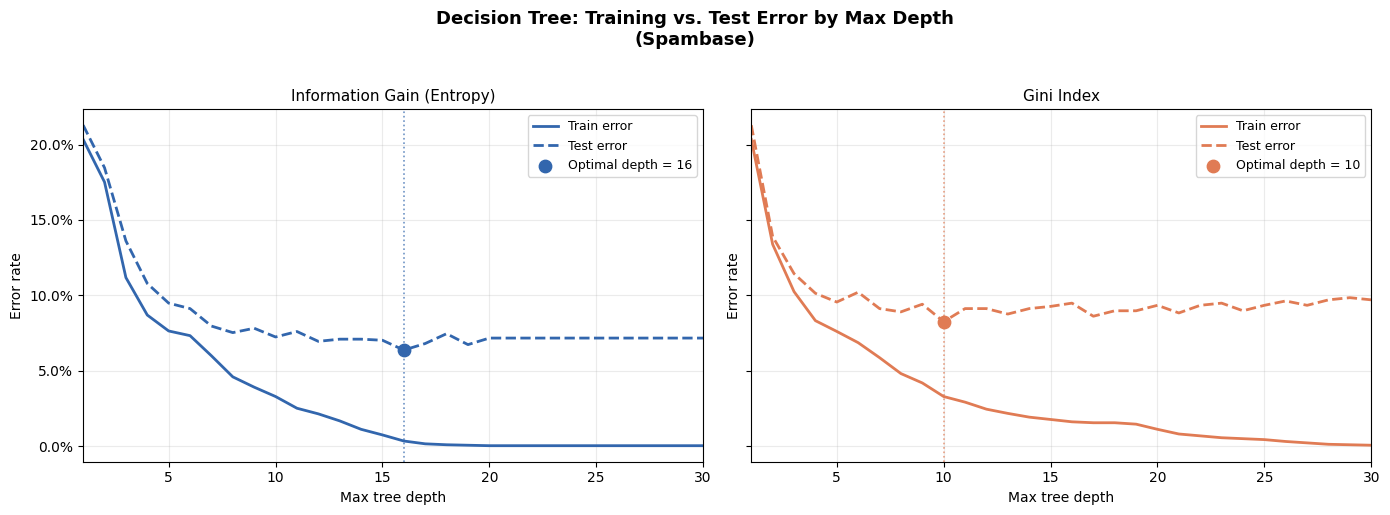

In [134]:

#3b) plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Decision Tree: Training vs. Test Error by Max Depth\n(Spambase)",
             fontsize=13, fontweight="bold", y=1.02)

BLUE   = "#3266ad"
ORANGE = "#e07b54"

for ax, crit, tr_err, te_err, opt, color in [
    (axes[0], "Information Gain (Entropy)",
     ig_train_err, ig_test_err, opt_ig_depth, BLUE),
    (axes[1], "Gini Index",
     gi_train_err, gi_test_err, opt_gi_depth, ORANGE),
]:
    ax.plot(depths, tr_err,
            color=color, lw=2, label="Train error")
    ax.plot(depths, te_err,
            color=color, lw=2, ls="--", label="Test error")
    ax.axvline(opt, color=color, lw=1.2, ls=":", alpha=0.7)
    ax.scatter([opt], [te_err[opt - 1]],
               color=color, zorder=5, s=80,
               label=f"Optimal depth = {opt}")

    ax.set_title(crit, fontsize=11)
    ax.set_xlabel("Max tree depth", fontsize=10)
    ax.set_ylabel("Error rate", fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
    ax.legend(fontsize=9)
    ax.grid(axis="both", alpha=0.25)
    ax.set_xlim(1, MAX_DEPTH)

plt.tight_layout()
plt.show()

Observations: From the graph
- Train error drops consistently for both criteria as depth increases, a deeper tree always fits the training data better, eventually alsmost reaching zero.
- Test error forms a U-shaped curve. It decreases as the tree gains expressiveness, hits a minimum, and then rises again as the tree starts overfitting noise.
- Information Gain achieves its minimum test error at depth 16 (6.37%), while Gini bottoms out much earlier at depth 10 (8.25%).
- Beyond their respective optima, both test error curves flatten or creep upward, adding more depth hurts generalization.

Recommended depth:
- 16 (Information Gain). At this depth the model achieves its best test error of 6.37% wich is better than the unpruned tree (7.17%) and way better than shallow trees. The Gini criterion peaks at depth 10 but never matches the quality of the optimal IG tree, so Information Gain with max_depth=16 is the recommended configuration overall.

### Problem 2:

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


DATA_PATH   = "spambase.data"
TEST_SIZE   = 0.30
RANDOM_SEED = 42
T_VALUES    = [10, 50, 100, 500]

FEATURE_NAMES = [f"feature_{i}" for i in range(57)]

In [136]:
 #data loading
data = pd.read_csv(DATA_PATH, header=None)
X = data.iloc[:, :57].values
y = data.iloc[:, 57].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

print(f"Dataset:   {len(data)} samples  |  57 features")
print(f"Train set: {len(X_train)} samples  |  Test set: {len(X_test)} samples\n")



Dataset:   4601 samples  |  57 features
Train set: 3220 samples  |  Test set: 1381 samples



In [137]:

#classifier function
def evaluate(clf, X_tr, y_tr, X_te, y_te):
    y_tr_pred = clf.predict(X_tr)
    y_te_pred = clf.predict(X_te)
    y_te_prob = clf.predict_proba(X_te)[:, 1]
    return {
        "train_acc": accuracy_score(y_tr, y_tr_pred),
        "test_acc":  accuracy_score(y_te, y_te_pred),
        "train_f1":  f1_score(y_tr, y_tr_pred),
        "test_f1":   f1_score(y_te, y_te_pred),
        "test_auc":  roc_auc_score(y_te, y_te_prob),
    }



In [138]:

#1. Random Forest sweep over T
print("Random Forest (T ∈ {10, 50, 100, 500})")
print("-" * 62)
print(f"  {'T':>5} | {'Train Acc':>10} {'Test Acc':>10} "
      f"{'Train F1':>10} {'Test F1':>10} {'AUC':>8}")
print("  " + "─" * 58)

rf_results = {}
rf_T500    = None

for T in T_VALUES:
    clf = RandomForestClassifier(
        n_estimators=T, random_state=RANDOM_SEED, n_jobs=-1
    )
    clf.fit(X_train, y_train)
    m = evaluate(clf, X_train, y_train, X_test, y_test)
    rf_results[T] = m
    if T == 500:
        rf_T500 = clf

    print(f"  {T:>5} | {m['train_acc']:>10.4f} {m['test_acc']:>10.4f} "
          f"{m['train_f1']:>10.4f} {m['test_f1']:>10.4f} {m['test_auc']:>8.4f}")


Random Forest (T ∈ {10, 50, 100, 500})
--------------------------------------------------------------
      T |  Train Acc   Test Acc   Train F1    Test F1      AUC
  ──────────────────────────────────────────────────────────
     10 |     0.9960     0.9442     0.9949     0.9270   0.9812
     50 |     0.9991     0.9544     0.9988     0.9411   0.9849
    100 |     0.9997     0.9558     0.9996     0.9430   0.9859
    500 |     0.9997     0.9566     0.9996     0.9439   0.9862


The gains are large going from T=10 to T=50, then rapidly diminish. Beyond T=100 improvements are marginal meaning the ensemble has effectively converged. This is expected because averaging more trees reduces variance, but only up to a point.


In [139]:

#2 Best Decision Tree (from model 1) for comparison
print("Comparison: Decision Tree vs. Random Forest T=500")
print("-" * 62)

dt_best = DecisionTreeClassifier(
    criterion="entropy", max_depth=16, random_state=RANDOM_SEED
)
dt_best.fit(X_train, y_train)
m_dt = evaluate(dt_best, X_train, y_train, X_test, y_test)
m_rf = rf_results[500]

print(f"\n  {'Metric':<20} {'Decision Tree':>15} {'RF T=500':>12}")
print("  " + "─" * 48)
for metric, label in [
    ("train_acc", "Train Accuracy"),
    ("test_acc",  "Test Accuracy"),
    ("train_f1",  "Train F1"),
    ("test_f1",   "Test F1"),
    ("test_auc",  "Test AUC"),
]:
    dt_val = m_dt[metric]
    rf_val = m_rf[metric]
    delta  = rf_val - dt_val
    sign   = "+" if delta >= 0 else ""
    print(f"  {label:<20} {dt_val:>15.4f} {rf_val:>12.4f}  ({sign}{delta:.4f})")


Comparison: Decision Tree vs. Random Forest T=500
--------------------------------------------------------------

  Metric                 Decision Tree     RF T=500
  ────────────────────────────────────────────────
  Train Accuracy                0.9966       0.9997  (+0.0031)
  Test Accuracy                 0.9363       0.9566  (+0.0203)
  Train F1                      0.9957       0.9996  (+0.0040)
  Test F1                       0.9187       0.9439  (+0.0253)
  Test AUC                      0.9361       0.9862  (+0.0502)


Observations:
- Random Forest (T=500) outperforms the best pruned Decision Tree (IG, depth=16) across every metric.
- The most notable test data gains are in F1 (+0.0253) and AUC (+0.0502), suggesting the forest is meaningfully better at identifying spam and ranking probabilities.
- Both models achieve near-identical train accuracy ( around 99.6–99.97%), but the RF generalizes substantially better on unseen data, because bagging with random feature subsets at each split reduces the variance that causes a single tree to overfit.

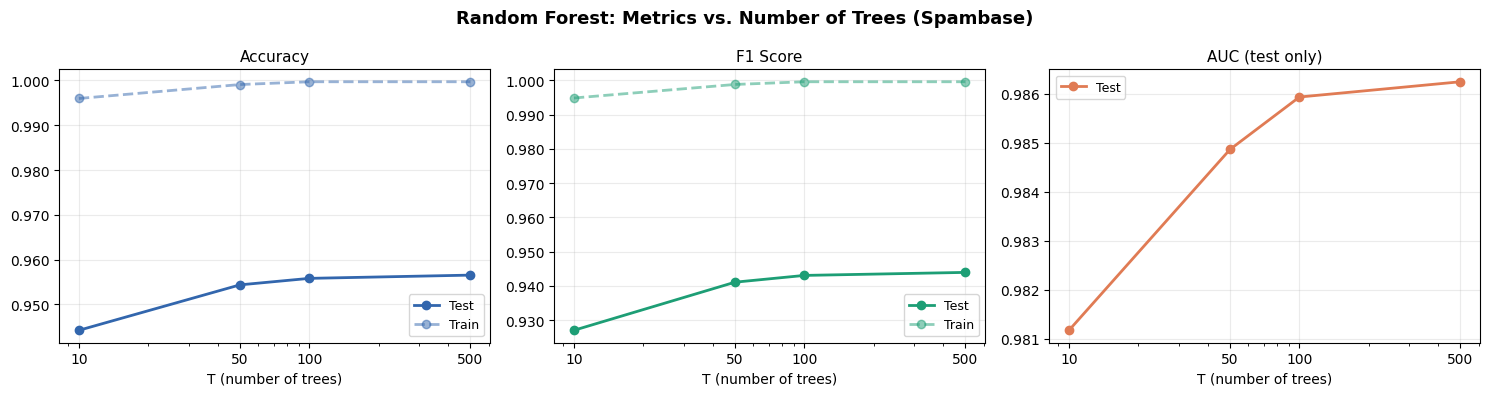

In [140]:

#3a) Plot: metrics as T increases
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Random Forest: Metrics vs. Number of Trees (Spambase)",
             fontsize=13, fontweight="bold")

BLUE   = "#3266ad"
GREEN  = "#1d9e75"
ORANGE = "#e07b54"

metric_configs = [
    ("test_acc",  "train_acc", "Accuracy",  BLUE),
    ("test_f1",   "train_f1",  "F1 Score",  GREEN),
    ("test_auc",  None,        "AUC (test only)", ORANGE),
]

for ax, (test_key, train_key, title, color) in zip(axes, metric_configs):
    test_vals  = [rf_results[T][test_key]  for T in T_VALUES]
    ax.plot(T_VALUES, test_vals,  color=color, lw=2, marker="o", label="Test")
    if train_key:
        train_vals = [rf_results[T][train_key] for T in T_VALUES]
        ax.plot(T_VALUES, train_vals, color=color, lw=2, marker="o",
                ls="--", alpha=0.5, label="Train")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("T (number of trees)", fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(T_VALUES)
    ax.set_xticklabels(T_VALUES)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.3f}"))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


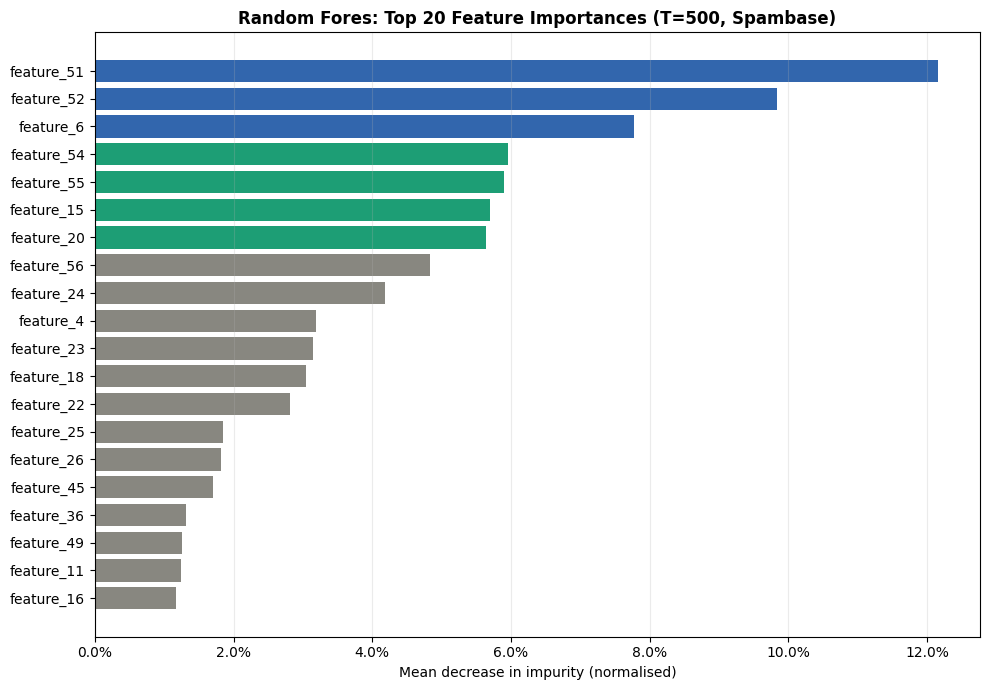


  Rank   Feature                               Importance
  ──────────────────────────────────────────────────────
  1      feature_51                                0.1215
  2      feature_52                                0.0984
  3      feature_6                                 0.0778
  4      feature_54                                0.0596
  5      feature_55                                0.0589
  6      feature_15                                0.0570
  7      feature_20                                0.0565
  8      feature_56                                0.0483
  9      feature_24                                0.0419
  10     feature_4                                 0.0319
  11     feature_23                                0.0315
  12     feature_18                                0.0305
  13     feature_22                                0.0281
  14     feature_25                                0.0185
  15     feature_26                                0.0182
  16     featu

In [141]:

#3b: variable importance
importances = rf_T500.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
top_n       = 20

top_names  = [FEATURE_NAMES[i] for i in sorted_idx[:top_n]]
top_scores = importances[sorted_idx[:top_n]]

fig, ax = plt.subplots(figsize=(10, 7))
colors = [BLUE if i < 3 else GREEN if i < 7 else "#888780"
          for i in range(top_n)]

ax.barh(range(top_n), top_scores[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel("Mean decrease in impurity (normalised)", fontsize=10)
ax.set_title("Random Fores: Top 20 Feature Importances (T=500, Spambase)",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.1f}%"))
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

#importance table
print(f"\n  {'Rank':<6} {'Feature':<35} {'Importance':>12}")
print("  " + "─" * 54)
for rank, idx in enumerate(sorted_idx, 1):
    print(f"  {rank:<6} {FEATURE_NAMES[idx]:<35} {importances[idx]:>12.4f}")

### Problem 3: AdaBoost Ensemble

In [142]:

from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, roc_curve)

DATA_PATH   = "spambase.data"
TEST_SIZE   = 0.30
RANDOM_SEED = 42
T_VALUES    = [10, 50, 100, 500]

#load data
data = pd.read_csv(DATA_PATH, header=None)
X = data.iloc[:, :57].values
y = data.iloc[:, 57].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

print(f"Dataset:   {len(data)} samples  |  57 features")
print(f"Train set: {len(X_train)} samples  |  Test set: {len(X_test)} samples\n")


Dataset:   4601 samples  |  57 features
Train set: 3220 samples  |  Test set: 1381 samples



In [143]:

#classifier function
def evaluate(clf, X_tr, y_tr, X_te, y_te):
    y_tr_pred = clf.predict(X_tr)
    y_te_pred = clf.predict(X_te)
    y_te_prob = clf.predict_proba(X_te)[:, 1]
    return {
        "train_acc": accuracy_score(y_tr, y_tr_pred),
        "test_acc":  accuracy_score(y_te, y_te_pred),
        "train_f1":  f1_score(y_tr, y_tr_pred),
        "test_f1":   f1_score(y_te, y_te_pred),
        "test_auc":  roc_auc_score(y_te, y_te_prob),
        "test_prob": y_te_prob,
    }


def print_table(label, results):
    print(f"\n{'='*65}")
    print(f"  {label}")
    print(f"{'='*65}")
    print(f"  {'T':>5} | {'Train Acc':>10} {'Test Acc':>10} "
          f"{'Train F1':>10} {'Test F1':>10} {'AUC':>8}")
    print("  " + "─" * 58)
    for T, m in results.items():
        print(f"  {T:>5} | {m['train_acc']:>10.4f} {m['test_acc']:>10.4f} "
              f"{m['train_f1']:>10.4f} {m['test_f1']:>10.4f} "
              f"{m['test_auc']:>8.4f}")


In [152]:

#adaboost sweep
ada_results = {}
for T in T_VALUES:
    clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=T,
        random_state=RANDOM_SEED
    )
    clf.fit(X_train, y_train)
    ada_results[T] = evaluate(clf, X_train, y_train, X_test, y_test)

print_table("AdaBoost (decision stump base classifier)", ada_results)

#Random Forest sweep (for comparison)
rf_results = {}
for T in T_VALUES:
    clf = RandomForestClassifier(
        n_estimators=T, random_state=RANDOM_SEED, n_jobs=-1
    )
    clf.fit(X_train, y_train)
    rf_results[T] = evaluate(clf, X_train, y_train, X_test, y_test)



  AdaBoost (decision stump base classifier)
      T |  Train Acc   Test Acc   Train F1    Test F1      AUC
  ──────────────────────────────────────────────────────────
     10 |     0.9716     0.9710     0.9699     0.9694   0.9905
     50 |     0.9970     0.9951     0.9969     0.9949   1.0000
    100 |     1.0000     0.9990     1.0000     0.9990   1.0000
    500 |     1.0000     1.0000     1.0000     1.0000   1.0000


In [145]:


#2 Comparison table with only test metrics
print("  AdaBoost vs Random Forest: Test metrics")
print(f"{'-'*65}")
print(f"  {'T':>5} | {'Ada Acc':>9} {'RF Acc':>9} | "
      f"{'Ada F1':>8} {'RF F1':>8} | {'Ada AUC':>8} {'RF AUC':>8}")
print("  " + "─" * 62)
for T in T_VALUES:
    a, r = ada_results[T], rf_results[T]
    print(f"  {T:>5} | {a['test_acc']:>9.4f} {r['test_acc']:>9.4f} | "
          f"{a['test_f1']:>8.4f} {r['test_f1']:>8.4f} | "
          f"{a['test_auc']:>8.4f} {r['test_auc']:>8.4f}")


  AdaBoost vs Random Forest: Test metrics
-----------------------------------------------------------------
      T |   Ada Acc    RF Acc |   Ada F1    RF F1 |  Ada AUC   RF AUC
  ──────────────────────────────────────────────────────────────
     10 |    0.8979    0.9442 |   0.8703   0.9270 |   0.9589   0.9812
     50 |    0.9269    0.9544 |   0.9046   0.9411 |   0.9782   0.9849
    100 |    0.9334    0.9558 |   0.9145   0.9430 |   0.9813   0.9859
    500 |    0.9385    0.9566 |   0.9211   0.9439 |   0.9834   0.9862


AdaBoost vs Random Forest Comparisons:
- Random Forest outperforms AdaBoost on accuracy and F1 at every T value.
- At T=500, RF leads by around 1.8% in test accuracy (95.66% vs 93.85%) and +0.023 in F1. However, the AUC gap is much narrower: 0.986 vs 0.983, meaning both models rank spam probabilities almost equally well.
- RF's advantage is mainly in its hard classification threshold, not its underlying probability estimates.
- AdaBoost also improves more steeply as T increases (+4.06% accuracy from T=10→500 vs +1.24% for RF), suggesting it benefits more from additional estimators.


ROC AUCs - Decision Tree: 0.9361  |  RF T=100: 0.9859  |  AdaBoost T=100: 0.9813


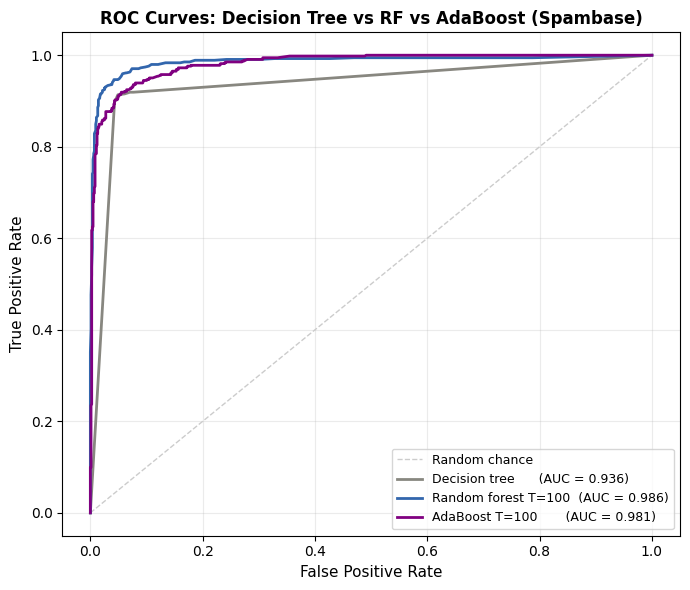

In [146]:

#3) ROC curves: DT vs RF (100) vs AdaBoost (100)
dt = DecisionTreeClassifier(criterion="entropy", max_depth=16, random_state=RANDOM_SEED)
dt.fit(X_train, y_train)
dt_prob = dt.predict_proba(X_test)[:, 1]

rf100 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf100.fit(X_train, y_train)
rf_prob = rf100.predict_proba(X_test)[:, 1]

ada100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=RANDOM_SEED
)
ada100.fit(X_train, y_train)
ada_prob = ada100.predict_proba(X_test)[:, 1]

dt_fpr,  dt_tpr,  _ = roc_curve(y_test, dt_prob)
rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)

dt_auc  = roc_auc_score(y_test, dt_prob)
rf_auc  = roc_auc_score(y_test, rf_prob)
ada_auc = roc_auc_score(y_test, ada_prob)

print(f"\nROC AUCs - Decision Tree: {dt_auc:.4f}  |  "
      f"RF T=100: {rf_auc:.4f}  |  AdaBoost T=100: {ada_auc:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], ls="--", color="#ccc", lw=1, label="Random chance")
ax.plot(dt_fpr,  dt_tpr,  color="#888780", lw=2,
        label=f"Decision tree      (AUC = {dt_auc:.3f})")
ax.plot(rf_fpr,  rf_tpr,  color=BLUE,      lw=2,
        label=f"Random forest T=100  (AUC = {rf_auc:.3f})")
ax.plot(ada_fpr, ada_tpr, color='PURPLE',    lw=2,
        label=f"AdaBoost T=100       (AUC = {ada_auc:.3f})")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves: Decision Tree vs RF vs AdaBoost (Spambase)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


### Problem 4:

In [147]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

dp   = "agaricus-lepiota.data"
TEST_SIZE   = 0.25
RANDOM_SEED = 42

#Load data
data = pd.read_csv(dp, header=None)



In [148]:
#Encoding every column (all categorical)
encoders = [LabelEncoder() for _ in range(data.shape[1])]
encoded  = data.copy()
for i in range(data.shape[1]):
    encoded[i] = encoders[i].fit_transform(data[i])

# Column 0 is the class label: 'e'=0 (edible), 'p'=1 (poisonous)
X = encoded.iloc[:, 1:].values
y = encoded.iloc[:, 0].values

# # of distinct categories per feature (needed for Laplace smoothing)
n_categories = [len(encoders[i + 1].classes_) for i in range(22)]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

print(f"Dataset:    {len(data)} samples  |  22 features (all categorical)")
print(f"Train set:  {len(X_train)} samples  |  Test set: {len(X_test)} samples")
print(f"Classes:    e=edible (0), p=poisonous (1)\n")


Dataset:    8124 samples  |  22 features (all categorical)
Train set:  6093 samples  |  Test set: 2031 samples
Classes:    e=edible (0), p=poisonous (1)



In [149]:

#1) Custom Naive Bayes implementation
class NaiveBayesCustom:
    """
    Categorical Naive Bayes with Laplace smoothing.

    Stores:
      self.priors      dict {class: P(class)}
      self.cond_probs  dict {class: [array of P(xi=v | class) per feature]}
    """

    def fit(self, X, y, n_categories):
        """
        Compute prior and conditional probabilities from training data.

        Parameters
        X            : (n_samples, n_features) integer-encoded feature matrix
        y            : (n_samples,) integer encoded class labels
        n_categories : list of ints : number of distinct values per feature
        """
        self.classes_     = np.unique(y)
        self.n_categories = n_categories
        n_train           = len(y)

        # Prior probabilities P(Y = c)
        self.priors = {c: np.sum(y == c) / n_train for c in self.classes_}

        # Conditional probabilities P(Xi = v | Y = c) with Laplace smoothing
        # Formula: (count(Xi=v, Y=c) + 1) / (count(Y=c) + k)
        # where k = number of distinct values for feature i
        self.cond_probs = {}
        for c in self.classes_:
            X_c  = X[y == c]
            n_c  = len(X_c)
            self.cond_probs[c] = []
            for feat_idx, k in enumerate(n_categories):
                counts = np.zeros(k)
                for val in X_c[:, feat_idx]:
                    counts[val] += 1
                probs = (counts + 1) / (n_c + k)   # Laplace smoothed
                self.cond_probs[c].append(probs)
        return self

    def predict_log_proba(self, X):
        """Return log-probs for each class (avoids underflow)."""
        log_probs = np.zeros((len(X), len(self.classes_)))
        for ci, c in enumerate(self.classes_):
            log_prior = np.log(self.priors[c])
            log_likelihood = np.zeros(len(X))
            for feat_idx in range(X.shape[1]):
                vals = X[:, feat_idx]
                log_likelihood += np.log(self.cond_probs[c][feat_idx][vals])
            log_probs[:, ci] = log_prior + log_likelihood
        return log_probs

    def predict(self, X):
        """Predict class labels for samples in X."""
        log_probs = self.predict_log_proba(X)
        return self.classes_[np.argmax(log_probs, axis=1)]



In [150]:


#2) Train custom NB
nb_custom = NaiveBayesCustom()
nb_custom.fit(X_train, y_train, n_categories)

# Report prior probabilities
print("  Prior probabilities (from training data)")
print("─" * 45)
for c, label in [(0, "Edible"), (1, "Poisonous")]:
    n_c = np.sum(y_train == c)
    print(f"  P(Y = {label:<10}) = {nb_custom.priors[c]:.4f}  "
          f"({n_c} / {len(y_train)} samples)")

# Report a sample of conditional probabilities (first feature, both classes)
print("\n  Sample: P(feature_0 = v | class)  [with Laplace smoothing]")
print(f"  {'Value':<8} {'P(v|Edible)':>14} {'P(v|Poisonous)':>16}")
print("  " + "─" * 38)
k0 = n_categories[0]
for v in range(k0):
    pe = nb_custom.cond_probs[0][0][v]
    pp = nb_custom.cond_probs[1][0][v]
    print(f"  {v:<8} {pe:>14.4f} {pp:>16.4f}")



  Prior probabilities (from training data)
─────────────────────────────────────────────
  P(Y = Edible    ) = 0.5180  (3156 / 6093 samples)
  P(Y = Poisonous ) = 0.4820  (2937 / 6093 samples)

  Sample: P(feature_0 = v | class)  [with Laplace smoothing]
  Value       P(v|Edible)   P(v|Poisonous)
  ──────────────────────────────────────
  0                0.0936           0.0129
  1                0.0003           0.0017
  2                0.3751           0.3955
  3                0.0547           0.1485
  4                0.0079           0.0003
  5                0.4684           0.4410


In [153]:
print("\n  Conditional probabilities for all features [with Laplace smoothing]")
for feat_idx in range(22):
    k = n_categories[feat_idx]
    print(f"\n  Feature {feat_idx} ({k} categories):")
    print(f"  {'Value':<8} {'P(v|Edible)':>14} {'P(v|Poisonous)':>16}")
    print("  " + "─" * 38)
    for v in range(k):
        pe = nb_custom.cond_probs[0][feat_idx][v]
        pp = nb_custom.cond_probs[1][feat_idx][v]
        print(f"  {v:<8} {pe:>14.4f} {pp:>16.4f}")


  Conditional probabilities for all features [with Laplace smoothing]

  Feature 0 (6 categories):
  Value       P(v|Edible)   P(v|Poisonous)
  ──────────────────────────────────────
  0                0.0936           0.0129
  1                0.0003           0.0017
  2                0.3751           0.3955
  3                0.0547           0.1485
  4                0.0079           0.0003
  5                0.4684           0.4410

  Feature 1 (4 categories):
  Value       P(v|Edible)   P(v|Poisonous)
  ──────────────────────────────────────
  0                0.3722           0.2016
  1                0.0003           0.0014
  2                0.2766           0.3611
  3                0.3509           0.4359

  Feature 2 (10 categories):
  Value       P(v|Edible)   P(v|Poisonous)
  ──────────────────────────────────────
  0                0.0114           0.0299
  1                0.0082           0.0031
  2                0.1459           0.2182
  3                0.2486     

In [151]:

#3 Compute accuracy, precision, recall, and F1 score for your Naive Bayes classifier on the testing data.
y_pred_custom = nb_custom.predict(X_test)

metrics_custom = {
    "Accuracy":  accuracy_score(y_test, y_pred_custom),
    "Precision": precision_score(y_test, y_pred_custom),
    "Recall":    recall_score(y_test, y_pred_custom),
    "F1 Score":  f1_score(y_test, y_pred_custom),
}

# alpha=1.0 corresponds to Laplace smoothing — equivalent to our implementation
nb_pkg = CategoricalNB(alpha=1.0)
nb_pkg.fit(X_train, y_train)
y_pred_pkg = nb_pkg.predict(X_test)

metrics_pkg = {
    "Accuracy":  accuracy_score(y_test, y_pred_pkg),
    "Precision": precision_score(y_test, y_pred_pkg),
    "Recall":    recall_score(y_test, y_pred_pkg),
    "F1 Score":  f1_score(y_test, y_pred_pkg),
}


# comparison table
print("  Custom NB vs CategoricalNB (sklearn)")
print(f"{'-'*55}")
print(f"  {'Metric':<14} {'Custom NB':>12} {'Package NB':>12} {'Match':>8}")
print("  " + "─" * 55)
for metric in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    c_val = metrics_custom[metric]
    p_val = metrics_pkg[metric]
    match = "yes" if abs(c_val - p_val) < 1e-8 else f"diff={abs(c_val-p_val):.6f}"
    print(f"  {metric:<14} {c_val:>12.4f} {p_val:>12.4f} {match:>8}")




  Custom NB vs CategoricalNB (sklearn)
-------------------------------------------------------
  Metric            Custom NB   Package NB    Match
  ───────────────────────────────────────────────────────
  Accuracy             0.9527       0.9527      yes
  Precision            0.9911       0.9911      yes
  Recall               0.9101       0.9101      yes
  F1 Score             0.9489       0.9489      yes


4) Key observations
- Priors are almost balanced: P(Edible)=0.518, P(Poisonous)=0.482, so the classifier isn't heavily biased toward either class from the start.
- Precision vs Recall asymmetry is the most notable result.
- Precision (0.991) is very high. When the model predicts poisonous, it's almost always right.
- But Recall (0.910) is lower, meaning  aorund 9% of actually poisonous mushrooms are being classified as edible. In a food-safety context this is the dangerous error type (false negatives), and a 9% miss rate on poisonous mushrooms would be unacceptable in practice.

NB underperforms because Naive Bayes assumes all features are conditionally independent given the class. Mushroom attributes like odor and gill color are likely correlated, violating this assumption. Despite that, 95.27% accuracy is still strong for such a simple model.

Custom NB vs package: The results are exactly identical because both use the same Laplace smoothing formula (alpha=1.0) and the same categorical likelihood computation which confirms the custom implementation is  equivalent to sklearn's Naive bayes